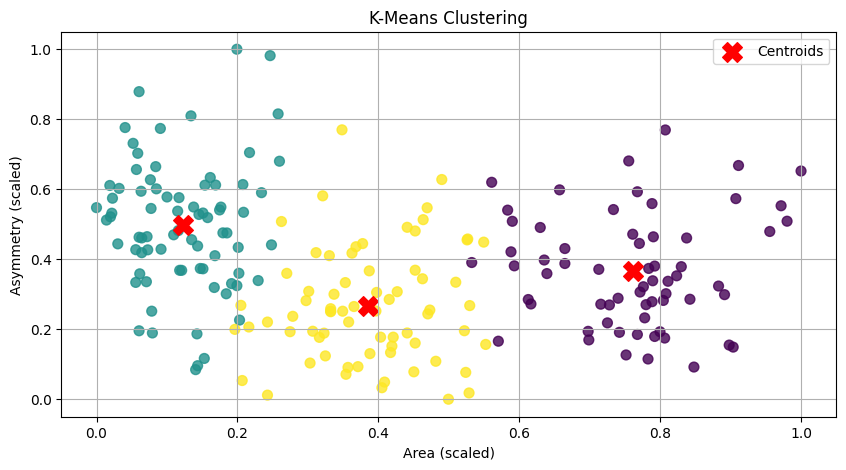

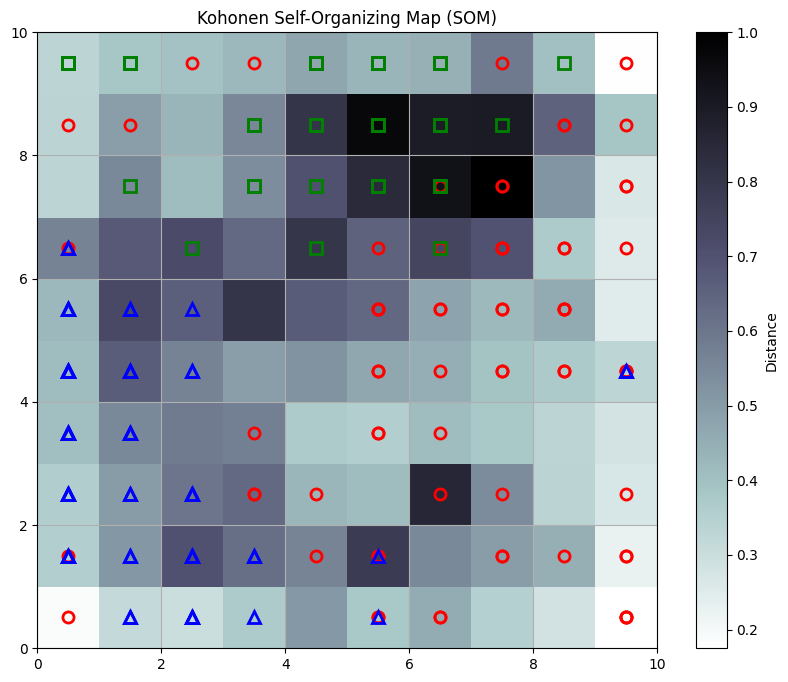

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from minisom import MiniSom

url_seeds = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
columns_seeds = ['area', 'perimeter', 'compactness', 'length', 'width', 'asymmetry', 'groove', 'species']
df_seeds = pd.read_csv(url_seeds, sep=r'\s+', names=columns_seeds)

X_seeds = df_seeds.drop('species', axis=1).values
y_seeds = df_seeds['species'].values

scaler_seeds = MinMaxScaler()
X_seeds_scaled = scaler_seeds.fit_transform(X_seeds)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_seeds_scaled)

plt.figure(figsize=(10, 5))
plt.scatter(X_seeds_scaled[:, 0], X_seeds_scaled[:, 5], c=kmeans_labels, cmap='viridis', s=50, alpha=0.8)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 5], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Area (scaled)')
plt.ylabel('Asymmetry (scaled)')
plt.legend()
plt.grid(True)
plt.show()

som = MiniSom(x=10, y=10, input_len=7, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_seeds_scaled)
som.train_random(X_seeds_scaled, num_iteration=500)

plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')
markers = ['o', 's', '^']
colors = ['r', 'g', 'b']
for i, x in enumerate(X_seeds_scaled):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, markers[y_seeds[i]-1],
             markerfacecolor='None', markeredgecolor=colors[y_seeds[i]-1],
             markersize=8, markeredgewidth=2)
plt.title('Kohonen Self-Organizing Map (SOM)')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.grid(True)
plt.show()

df_fish = pd.read_csv('Fish.csv')
df_fish = df_fish[df_fish['Weight'] > 0]
df_fish_encoded = pd.get_dummies(df_fish, columns=['Species'], drop_first=True)

X_fish = df_fish_encoded.drop('Weight', axis=1).values
y_fish = df_fish_encoded['Weight'].values

X_train, X_test, y_train, y_test = train_test_split(X_fish, y_fish, test_size=0.25, random_state=42)

scaler_fish = StandardScaler()
X_train_scaled = scaler_fish.fit_transform(X_train)
X_test_scaled = scaler_fish.transform(X_test)

mlp_base = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=42)
mlp_perfect = TransformedTargetRegressor(regressor=mlp_base, transformer=StandardScaler())
mlp_perfect.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_perfect.predict(X_test_scaled)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

### Выводы:
1.  **K-Means кластеризация** успешно разбила данные на 3 компактные, относительно изолированные группы, что согласуется с тремя известными сортами пшеницы.
2.  **Самоорганизующаяся карта Кохонена (SOM)** визуализировала плавные переходы между сортами и выявила пограничные структуры зерен, показывая топологическое распределение данных.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

df_fish = pd.read_csv('Fish.csv')
df_fish = df_fish[df_fish['Weight'] > 0]
df_fish_encoded = pd.get_dummies(df_fish, columns=['Species'], drop_first=True)

X_fish = df_fish_encoded.drop('Weight', axis=1).values
y_fish = df_fish_encoded['Weight'].values

X_train, X_test, y_train, y_test = train_test_split(X_fish, y_fish, test_size=0.25, random_state=42)

scaler_fish = StandardScaler()
X_train_scaled = scaler_fish.fit_transform(X_train)
X_test_scaled = scaler_fish.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mlp_base = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=2000, random_state=42)
mlp_perfect = TransformedTargetRegressor(
    regressor=mlp_base,
    transformer=StandardScaler()
)
mlp_perfect.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_perfect.predict(X_test_scaled)

print("--- MLP Regression Results ---")
print(f"R²: {r2_score(y_test, y_pred_mlp):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_mlp):.2f} g")

print("\n--- Linear Regression Results ---")
print(f"R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_lr):.2f} g")

--- MLP Regression Results ---
R²: 0.9702
RMSE: 62.55 g

--- Linear Regression Results ---
R²: 0.9482
RMSE: 82.41 g


### Выводы:
1.  **Нейросетевая регрессия (MLPRegressor)** показала значительно лучшие результаты с R² = 0.9702 и RMSE = 62.55 г, что свидетельствует о хорошей способности модели предсказывать вес рыбы на основе предоставленных признаков.
2.  **Линейная регрессия** также продемонстрировала неплохие результаты с R² = 0.9482 и RMSE = 82.41 г, но немного уступила нейросети в точности предсказаний.